# Complex Number Inverse — Geometric Intuition

**The key insight:** complex multiplication is not just algebra — it's *geometry*.

Every complex number $\alpha = a + bi$ does two things when you multiply by it:

1. **Scales** everything by $|\alpha| = \sqrt{a^2 + b^2}$
2. **Rotates** everything by $\arg(\alpha) = \arctan\!\left(\frac{b}{a}\right)$

So the **inverse** $\beta$ must do the opposite:

1. **Shrink** by $|\alpha|$ (i.e. divide by $|\alpha|^2$)
2. **Rotate backwards** (i.e. flip the sign of $i$ → take the conjugate $\bar{\alpha} = a - bi$)

That's the whole story. We'll visualize every step with $\alpha = -2 + 2i$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from sympy import sqrt, atan2, pi, simplify, conjugate, Rational, I, latex
from sympy import re as sym_re, im as sym_im

# Safe style selection
_style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid'
plt.style.use(_style)

print("Libraries loaded.")


Libraries loaded.


---

## Step 1 — Plot $\alpha = -2 + 2i$ as a Vector

A complex number is just a point (or arrow) in the plane.

- Real part $\to$ horizontal axis
- Imaginary part $\to$ vertical axis

So $\alpha = -2 + 2i$ lives at the point $(-2,\ 2)$ — two steps left, two steps up.


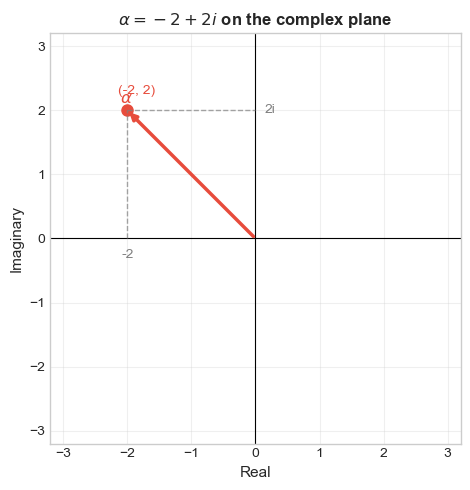

alpha = -2 + 2i  →  point (-2, 2) in the plane


In [2]:
def make_axes(ax, lim=3.5, title=""):
    """Helper: draw clean complex plane axes."""
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlabel("Real", fontsize=11)
    ax.set_ylabel("Imaginary", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

def draw_vector(ax, x, y, color, label, lw=2.5):
    """Draw a vector from origin to (x, y)."""
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw))
    offset_x = 0.12 * np.sign(x) if x != 0 else 0.12
    offset_y = 0.12 * np.sign(y) if y != 0 else 0.12
    ax.text(x + offset_x, y + offset_y, label, color=color, fontsize=12, fontweight='bold')

# ── Plot alpha ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
make_axes(ax, lim=3.2, title=r"$\alpha = -2 + 2i$ on the complex plane")

draw_vector(ax, -2, 2, '#e74c3c', r'$\alpha$')
ax.plot(-2, 2, 'o', color='#e74c3c', markersize=8)
ax.text(-2 - 0.15, 2 + 0.25, "(-2, 2)", color='#e74c3c', fontsize=10)

# tick the coordinates
ax.plot([-2, -2], [0, 2], '--', color='gray', lw=1, alpha=0.7)
ax.plot([-2, 0], [2, 2], '--', color='gray', lw=1, alpha=0.7)
ax.text(-2, -0.3, "-2", ha='center', color='gray', fontsize=10)
ax.text(0.15, 2, "2i", va='center', color='gray', fontsize=10)

plt.tight_layout()
plt.show()
print("alpha = -2 + 2i  →  point (-2, 2) in the plane")


---

## Step 2 — Modulus and Argument

Every complex number has two geometric properties:

| Property | Formula | Value for $\alpha = -2+2i$ |
|----------|---------|---------------------------|
| **Modulus** (length) | $\|\alpha\| = \sqrt{a^2+b^2}$ | $\sqrt{4+4} = 2\sqrt{2}$ |
| **Argument** (angle) | $\arg(\alpha) = \text{arctan2}(b, a)$ | $135°$ |

The vector points to the **top-left**, which is exactly 135° from the positive real axis.

Multiplying any number by $\alpha$ will **stretch it by $2\sqrt{2}$** and **spin it by $135°$**.


alpha = -2 + 2i
|alpha| = sqrt(4 + 4) = sqrt(8) = 2.8284  = 2*sqrt(2) = 2.8284
arg(alpha) = arctan2(2, -2) = 135.0 degrees


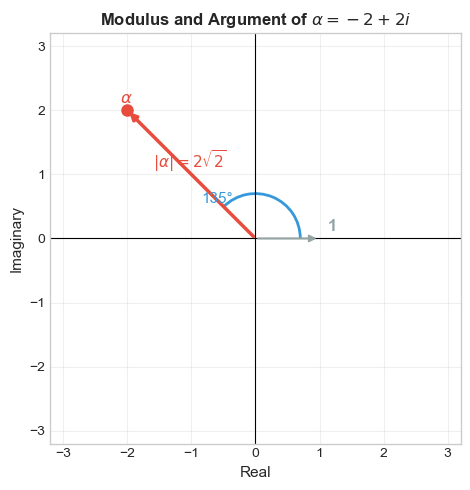

In [9]:
a, b = -2, 2
modulus = np.sqrt(a**2 + b**2)
angle_rad = np.arctan2(b, a)
angle_deg = np.degrees(angle_rad)

print(f"alpha = {a} + {b}i")
print(f"|alpha| = sqrt({a**2} + {b**2}) = sqrt({a**2 + b**2}) = {modulus:.4f}  = 2*sqrt(2) = {2*np.sqrt(2):.4f}")
print(f"arg(alpha) = arctan2({b}, {a}) = {angle_deg:.1f} degrees")

# ── Plot with angle annotation ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
make_axes(ax, lim=3.2, title=r"Modulus and Argument of $\alpha = -2+2i$")

draw_vector(ax, a, b, '#e74c3c', r'$\alpha$')
ax.plot(a, b, 'o', color='#e74c3c', markersize=8)

# Arc showing the 135-degree angle
arc = mpatches.Arc((0, 0), 1.4, 1.4, angle=0,
                   theta1=0, theta2=angle_deg,
                   color='#3498db', lw=2)
ax.add_patch(arc)

# Angle label
ax.text(-0.85, 0.55, "135°", color='#3498db', fontsize=11)

# Modulus label along the vector
mid_x, mid_y = a / 2, b / 2
ax.text(mid_x - 0.6, mid_y + 0.1, r"$|{\alpha}| = 2\sqrt{2}$", color='#e74c3c', fontsize=11)

# Reference unit vector for scale
draw_vector(ax, 1, 0, '#95a5a6', "1", lw=1.5)

plt.tight_layout()
plt.show()


---

## Step 3 — Multiplication = Rotation + Scaling

To really see what $\alpha$ *does*, let's watch it act on the unit vector $1$ (the point $(1, 0)$).

Multiplying $1 \times \alpha$:
- The unit vector gets **stretched by $2\sqrt{2}$**
- And **rotated by $135°$**

Result: it lands on $\alpha$ itself (which makes sense — $1 \times \alpha = \alpha$).

But the same thing happens to **any** input. That's the pattern — every multiplication by $\alpha$ = same spin + same stretch applied to whatever you started with.


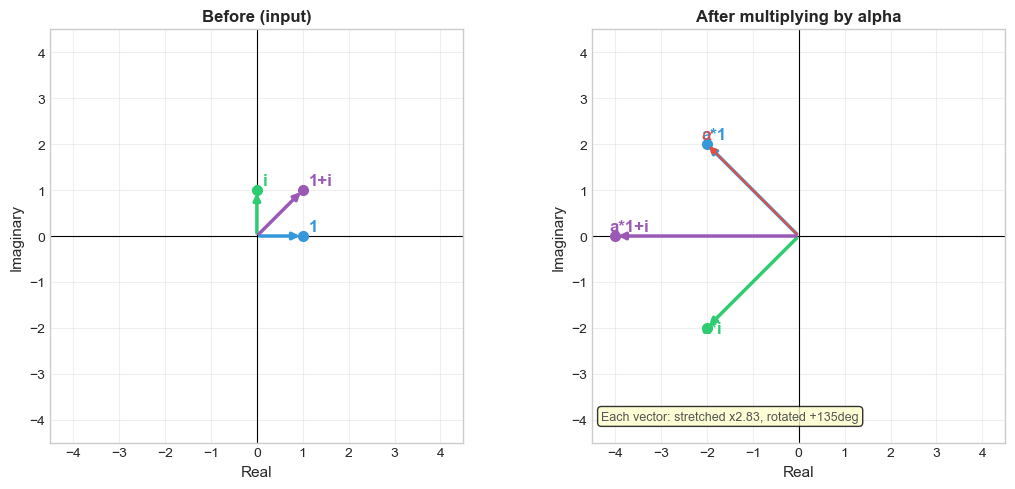

In [10]:
# Show how alpha transforms a few sample vectors
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

alpha = complex(a, b)

sample_vectors = [
    (complex(1, 0),   '#3498db',  '1'),
    (complex(0, 1),   '#2ecc71',  'i'),
    (complex(1, 1),   '#9b59b6',  '1+i'),
]

for ax, title_suffix in zip(axes, ["Before (input)", "After multiplying by alpha"]):
    make_axes(ax, lim=4.5, title=title_suffix)

ax_before, ax_after = axes

for z, color, label in sample_vectors:
    draw_vector(ax_before, z.real, z.imag, color, label)
    ax_before.plot(z.real, z.imag, 'o', color=color, markersize=7)

    w = alpha * z
    draw_vector(ax_after, w.real, w.imag, color, f"a*{label}")
    ax_after.plot(w.real, w.imag, 'o', color=color, markersize=7)

# Draw alpha on the after-panel for reference
draw_vector(ax_after, a, b, '#e74c3c', r'$\alpha$', lw=1.5)

# Annotation
axes[1].text(-4.3, -4.0,
    f"Each vector: stretched x{modulus:.2f}, rotated +{angle_deg:.0f}deg",
    fontsize=9, color='#555555',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffffcc', alpha=0.8))

plt.tight_layout()
plt.show()


---

## Step 4 — The Conjugate: Flipping the Rotation

To **undo** the 135° rotation, we need something that rotates by **-135°**.

The trick: just **flip the sign of $i$**.

$$\alpha = -2 + 2i \quad \xrightarrow{\text{conjugate}} \quad \bar{\alpha} = -2 - 2i$$

- Same horizontal position $(-2)$
- Opposite vertical: was $+2$, now $-2$
- This is a **reflection across the real axis** (x-axis)

The angle goes from $+135°$ to $-135°$. That's exactly the backwards rotation we need.

The length stays the same: $|\bar{\alpha}| = \sqrt{(-2)^2 + (-2)^2} = 2\sqrt{2}$.


alpha     = -2 + 2i   angle = +135 deg,  |alpha| = 2.8284
conjugate = -2 + -2i  angle = -135 deg,  |conj|  = 2.8284


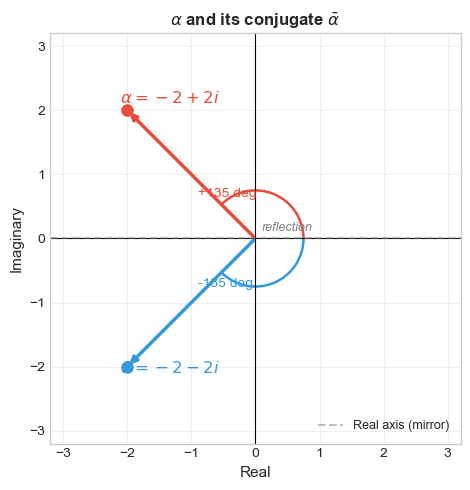

In [5]:
alpha_conj = complex(a, -b)
angle_conj_deg = np.degrees(np.arctan2(-b, a))

print(f"alpha     = {a} + {b}i   angle = +{angle_deg:.0f} deg,  |alpha| = {modulus:.4f}")
print(f"conjugate = {a} + {-b}i  angle = {angle_conj_deg:.0f} deg,  |conj|  = {np.abs(alpha_conj):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
make_axes(ax, lim=3.2, title=r"$\alpha$ and its conjugate $\bar{\alpha}$")

draw_vector(ax, a, b,    '#e74c3c', r'$\alpha = -2+2i$')
draw_vector(ax, a, -b,   '#3498db', r'$\bar{\alpha} = -2-2i$')

ax.plot(a,  b,  'o', color='#e74c3c', markersize=8)
ax.plot(a, -b,  'o', color='#3498db', markersize=8)

# Mirror line
ax.axhline(0, color='gray', lw=1.5, ls='--', alpha=0.5, label="Real axis (mirror)")

# Angle arcs
arc_pos = mpatches.Arc((0,0), 1.5, 1.5, angle=0, theta1=0, theta2=angle_deg,
                        color='#e74c3c', lw=1.8)
arc_neg = mpatches.Arc((0,0), 1.5, 1.5, angle=0, theta1=angle_conj_deg, theta2=0,
                        color='#3498db', lw=1.8)
ax.add_patch(arc_pos)
ax.add_patch(arc_neg)

ax.text(-0.9,  0.65, "+135 deg", color='#e74c3c', fontsize=10)
ax.text(-0.9, -0.75, "-135 deg", color='#3498db', fontsize=10)

ax.text(0.1, 0.12, "reflection", color='gray', fontsize=9, style='italic')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


---

## Step 5 — Compute the Inverse: Conjugate / Modulus²

The conjugate $\bar{\alpha}$ undoes the rotation — but it still has the same length $2\sqrt{2}$.

We need to **also undo the scaling**. So divide by $|\alpha|^2 = a^2 + b^2$:

$$\beta = \frac{\bar{\alpha}}{|\alpha|^2} = \frac{-2 - 2i}{8} = -\frac{1}{4} - \frac{1}{4}i$$

Now $\beta$:
- Has angle $-135°$ (rotation reversed)
- Has modulus $\dfrac{2\sqrt{2}}{8} = \dfrac{1}{2\sqrt{2}}$ (length is the reciprocal of $|\alpha|$)

When you multiply $\alpha \times \beta$, the angles add to $0°$ and the lengths multiply to $1$. That's exactly $1$.


In [ ]:
mod_sq = a**2 + b**2
beta = alpha_conj / mod_sq
beta_mod = np.abs(beta)
beta_angle_deg = np.degrees(np.arctan2(beta.imag, beta.real))

print(f"conjugate     = {alpha_conj}")
print(f"|alpha|^2     = {a}^2 + {b}^2 = {mod_sq}")
print(f"beta = conj / |alpha|^2 = ({alpha_conj}) / {mod_sq} = {beta}")
print(f"|beta|        = {beta_mod:.6f}  (= 1 / |alpha| = {1/modulus:.6f})")
print(f"arg(beta)     = {beta_angle_deg:.1f} degrees")

# ── Plot alpha, conjugate, and beta together ──────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
make_axes(ax, lim=3.2, title=r"$\alpha$, $\bar{\alpha}$, and $\beta = \alpha^{-1}$")

draw_vector(ax, a, b,          '#e74c3c', r'$\alpha$')
draw_vector(ax, a, -b,         '#3498db', r'$\bar{\alpha}$')
draw_vector(ax, beta.real, beta.imag, '#27ae60', r'$\beta = \alpha^{-1}$')

ax.plot(a,  b,           'o', color='#e74c3c', markersize=8)
ax.plot(a, -b,           'o', color='#3498db', markersize=8)
ax.plot(beta.real, beta.imag, 'o', color='#27ae60', markersize=8)

# Beta label with value
ax.text(beta.real - 0.9, beta.imag - 0.3,
        f"(-1/4 - 1/4 i)", color='#27ae60', fontsize=9)

# Length annotation for beta
ax.annotate("", xy=(beta.real, beta.imag), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color='#27ae60', lw=2.5))

plt.tight_layout()
plt.show()

print(f"\nAll three vectors:")
print(f"  alpha = (-2, 2),  length = {modulus:.3f},  angle = +{angle_deg:.0f} deg")
print(f"  conj  = (-2,-2),  length = {modulus:.3f},  angle = {angle_conj_deg:.0f} deg")
print(f"  beta  = ({beta.real:.3f},{beta.imag:.3f}), length = {beta_mod:.3f},  angle = {beta_angle_deg:.0f} deg")


---

## Step 6 — The "Undo" in 4 Frames

Here's what happens step by step when we apply $\beta$ to undo $\alpha$:

| Frame | Operation | Angle | Length |
|-------|-----------|-------|--------|
| Start | $\alpha$ acting on $1$ | $+135°$ | $2\sqrt{2}$ |
| Step 1 | Reflect: take conjugate | $-135°$ | $2\sqrt{2}$ |
| Step 2 | Shrink: divide by $|\alpha|^2 = 8$ | $-135°$ | $\frac{1}{2\sqrt{2}}$ |
| Final | $\alpha \cdot \beta = 1$ | $0°$ | $1$ |

The plot below shows these four stages.


In [ ]:
# 4-frame "undo" visualization
frames = [
    (complex(a, b),           '#e74c3c', r'Frame 1: $\alpha$ (+135 deg, len=2$\sqrt{2}$)'),
    (complex(a, -b),          '#3498db', r'Frame 2: conjugate $\bar{\alpha}$ (-135 deg, len=2$\sqrt{2}$)'),
    (complex(a, -b) / mod_sq, '#27ae60', r'Frame 3: $\beta = \bar{\alpha}/|\alpha|^2$ (-135 deg, short)'),
    (complex(1, 0),            '#f39c12', r'Frame 4: $\alpha \cdot \beta = 1$ (0 deg, len=1)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (z, color, title) in zip(axes, frames):
    make_axes(ax, lim=3.2, title=title)
    draw_vector(ax, z.real, z.imag, color, "")
    ax.plot(z.real, z.imag, 'o', color=color, markersize=9)

    angle_d = np.degrees(np.arctan2(z.imag, z.real))
    length   = np.abs(z)
    ax.text(-3.0, -3.0,
            f"angle={angle_d:.0f} deg\nlen={length:.3f}",
            fontsize=9, color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Draw unit circle for reference
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), '--', color='gray', lw=0.8, alpha=0.4)

plt.suptitle("The 4-step undo: from alpha back to 1", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---

## Step 7 — Verify: Rotations Cancel, Lengths Cancel

Let's confirm the geometry numerically and symbolically.

**Angles add to zero:**

$$+135° + (-135°) = 0°$$

**Lengths multiply to one:**

$$2\sqrt{2} \times \frac{1}{2\sqrt{2}} = 1$$

**Algebraic check:** $\alpha \cdot \beta = (-2 + 2i)\!\left(-\tfrac{1}{4} - \tfrac{1}{4}i\right) = 1$

The final result is the vector $(1, 0)$ — sitting right on the real axis, length 1, angle 0°. That's exactly the complex number $1$.


In [ ]:
alpha_num = complex(a, b)
beta_num  = complex(beta.real, beta.imag)
product   = alpha_num * beta_num

print("=== Numerical verification ===")
print(f"alpha          = {alpha_num}")
print(f"beta           = {beta_num}")
print(f"alpha * beta   = {product}  (should be 1+0j)")
print()
print("=== Geometric cancellation ===")
print(f"  arg(alpha) + arg(beta) = {angle_deg:.1f} + {beta_angle_deg:.1f} = {angle_deg + beta_angle_deg:.1f} deg  (should be 0)")
print(f"  |alpha| * |beta|       = {modulus:.4f} * {beta_mod:.6f} = {modulus * beta_mod:.6f}  (should be 1)")

# ── Final plot: alpha, beta, and product (=1) ─────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
make_axes(ax, lim=3.2, title=r"Final result: $\alpha \cdot \beta = 1$")

draw_vector(ax, a, b,          '#e74c3c', r'$\alpha$')
draw_vector(ax, beta.real, beta.imag, '#27ae60', r'$\beta$')
draw_vector(ax, product.real, product.imag, '#f39c12', r'$\alpha\beta = 1$', lw=3)

ax.plot(a, b,               'o', color='#e74c3c', markersize=8)
ax.plot(beta.real, beta.imag, 'o', color='#27ae60', markersize=8)
ax.plot(product.real, product.imag, '*', color='#f39c12', markersize=14, zorder=5)

# Unit circle for reference
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), '--', color='gray', lw=1, alpha=0.4)

ax.text(product.real + 0.1, product.imag + 0.18, "(1, 0)", color='#f39c12', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Symbolic check with sympy ──────────────────────────────────────────────
from sympy import symbols, sqrt as sym_sqrt, simplify, I as sI, Rational as R

alpha_s = R(-2) + R(2)*sI
beta_s  = R(-1,4) + R(-1,4)*sI
result  = simplify(alpha_s * beta_s)
print(f"\nSymPy check: ({alpha_s}) * ({beta_s}) = {result}")


---

## Summary — The Full Geometric Story

$$\alpha = a + bi$$

| What $\alpha$ does | What $\alpha^{-1}$ must do |
|--------------------|---------------------------|
| Rotate by $+\theta$ | Rotate by $-\theta$ |
| Scale by $\|\alpha\|$ | Scale by $1/\|\alpha\|$ |

**How to build the inverse geometrically:**

1. **Flip** the imaginary part sign $\to$ you get $\bar{\alpha} = a - bi$ (the conjugate)
   - Same length, opposite angle — this undoes the rotation
2. **Divide** by $|\alpha|^2 = a^2 + b^2$
   - This shrinks the length to $\frac{|\alpha|}{|\alpha|^2} = \frac{1}{|\alpha|}$ — this undoes the scaling

$$\boxed{\alpha^{-1} = \frac{\bar{\alpha}}{|\alpha|^2} = \frac{a - bi}{a^2 + b^2}}$$

That formula isn't a trick — it's geometry: flip then shrink.
